# BEE 4750 Homework 1: Introduction to Using Julia

**Name**: Evan Sims

**ID**: 5359764

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

Pkg.add("Plots")
Pkg.add("Random")
Pkg.add("GraphRecipes")
Pkg.add("LaTeXStrings")
Pkg.add("Distributions")

  Activating project at `~/Documents/School/Senior/BEE 4750/bee4750-hw1-ems452`
   Installed SimpleTraits ─── v0.9.4
   Installed Unitful ──────── v1.23.1
   Installed StaticArrays ─── v1.9.14
   Installed ChainRulesCore ─ v1.25.2
   Installed Interpolations ─ v0.16.1
   Installed Graphs ───────── v1.13.0
Precompiling project...
   1666.7 ms  ✓ Rmath_jll
   1677.3 ms  ✓ EarCut_jll
   1840.4 ms  ✓ SimpleTraits
   1027.7 ms  ✓ OpenSpecFun_jll
   2800.0 ms  ✓ ChainRulesCore
   1523.2 ms  ✓ Rmath
   1648.6 ms  ✓ QuadGK
   1813.6 ms  ✓ ChainRulesCore → ChainRulesCoreSparseArraysExt
   1774.8 ms  ✓ LogExpFunctions → LogExpFunctionsChainRulesCoreExt
   3823.4 ms  ✓ SpecialFunctions
   6643.4 ms  ✓ ColorSchemes
   1067.1 ms  ✓ ColorVectorSpace → SpecialFunctionsExt
   2246.4 ms  ✓ HypergeometricFunctions
   3060.1 ms  ✓ SpecialFunctions → SpecialFunctionsChainRulesCoreExt
  10862.4 ms  ✓ StaticArrays
   3106.1 ms  ✓ StatsFuns
   1506.0 ms  ✓ StaticArrays → StaticArraysChainRulesCoreExt
   1097

Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [2]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [3]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [4]:
function minimum(array)
    # initialize the minimum value counter
    min_value = 1000 #changed to be a value larger than any values in the array
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


### 1.1 ANSWER:
The flaw in this code is that the initial minimum value is set to zero, which is already the lowest value in the array. The way the code tries to update this minimum value is by checking if it is less than the current min_value, but because the initial min_value that we set is zero, none of the values in the array are going to be lower, so it will not return the lowest value in the array. The fix should be setting the initial min_value to be something that is necessarily higher than anything in the array. This way, the min_value will immediately be reset to the first number in the array and the code can then properly compare each value in the array to the lowest value it has seen thus far in the array, removing influence from our arbitrary initial min_value. In this case, I set the initial value to 1000.

What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [5]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(grades)
  return average_grade
end
@show class_average(student_grades);

class_average(student_grades) = 94.4


https://discourse.julialang.org/t/mean-function-unknown/26844

I used the above source to better understand the mean function in julia. 

https://docs.julialang.org/en/v1/manual/variables-and-scoping/

I used the above source to understand how local and global variables work in Julia

### 1.2 ANSWER:
The first problem is that the function is never actually called, so there isn't any average grade calculated. To fix this, I called the function with the student_grades list as the input. Secondly, the "UndefVarError" error is saying the variable we are trying to print has not been assigned to anything. This happends here because the @show function is trying to show a local variable that is used within the function but globally has no meaning. Becasue we are in the global environment, average_grade has no value and is therefore undefined. To fix this, I just did @show class_average(student_grades) because this calls the function properly and returns the average grade by design of the function. There is no need to reference average_grade in the global environment when the average is already returned as the result of calling the function.

What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [6]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zeros(n_trials) #changed to zeros(), not zero()
# simulate number of passadieci rolls and count wins
for i in 1:n_trials
    outcomes[i] = (sum(passadieci()) > 11)
end
win_prob = (sum(outcomes) / n_trials) # compute average number of wins
@show win_prob;

win_prob = 0.382


https://www.jlhub.com/julia/manual/en/function/zero

The above function helped me understand what the zero function does in Julia from my python background, I know of a function called zeros to get an array of zeros instead of the incorrectly setting n_trials equal to zero

https://www.jlhub.com/julia/manual/en/function/MethodError

The above link helped me understand what the MethodError means generally

### 1.3 ANSWER
The methodError error is letting us know that come operation or function we are trying to perform can not occur on the type of input we gave it. In this case we were trying to index an integer, causing the methoderror. Once I corrected the zeros function, this was now an array that could properly be indexed.

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [8]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect .- m #changed to broadcast subtraction
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [0.2518251759279181, 0.24781648079434293, -0.16942679976132546, -0.4129833232118977, 0.161507035998238, -0.19182105961062723, 0.050389250552942744, -0.26925175540513957, 0.4653758533199549, 0.16062117376200258, 0.3160886284959331, -0.3191402433779871, -0.07837177486485203, 0.30263217620046945, -0.4074282812138704, 0.06438430929856997, -0.1508524620257492, -0.24306220312609217, 0.19188943494141286, -0.304522802448951, -0.4044119562837981, 0.2745716238532059, -0.16403822428243509, 0.17398456894660586, -0.13355786090208344, 0.031597679327905026, 0.09973694809717393, -0.20389109236007363, 0.3893547940929917, -0.3030429545084292, 0.015751410466095628, -0.2712324176529408, 0.32339748516387334, 0.07733789897034327, 0.4164423381778405, -0.4786817366827162, 0.2535610742210309, -0.3643065968800644, 0.455133866550151, 0.46026335159359055, -0.415971035654909, 0.33072346913341644, -0.06167151288280337, -0.5102512906214627, 0.12363446267242995, 0.36180595297895257, 0.24342

1000-element Vector{Float64}:
  0.2518251759279181
  0.24781648079434293
 -0.16942679976132546
 -0.4129833232118977
  0.161507035998238
 -0.19182105961062723
  0.050389250552942744
 -0.26925175540513957
  0.4653758533199549
  0.16062117376200258
  ⋮
  0.3798937438207667
  0.06804746284670538
 -0.06514293678230532
  0.4284483776488426
  0.34525825665908283
  0.2557566494537715
  0.29707465541732725
  0.34625617923180607
  0.1429135947996315

https://stackoverflow.com/questions/44393145/best-way-to-subtract-vector-from-matrix-in-julia

I used the above resource to what the error meant by "use broadcasting with dot syntax: array .-"

### 1.4 ANSWER
The MethodError again means we are trying to do an operation with element types it doesn't support. The problem here is that we can't use the "-" operator to subtract a float from an array. We need to do something call broadcast subtraction to remove the mean (a float) from each element in an vector (array) individually. This is done by simply adding a "." before the "-"


What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

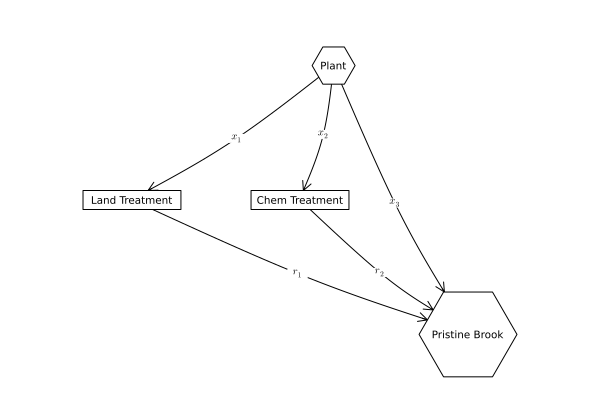

In [9]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => L"x_1", (1,3) => L"x_2", (1, 4) => L"x_3",(2, 4) => L"r_1",(3, 4) => L"r_2")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).


### Model Definition

#### Constraints on model:
Flow from Plant to land disposal, chemical treatment and directly to Brook:

$0 <= x_1$

$0 <= x_2$   

$0 <= x_3$    

Total possible wastewater flow from Plant:  $x_1 + x_2 + x_3 <= 100 m^3/d$

Max allowable effluent load to Brook: $r_1+r_2+x_1 <= 20 kg/d$

This set of constraints prevents reverse (negative) flows within the system, limits the total outflows from to the plant to no more than 100 $m^3/d$ and sets the maximum YUK released into the Brook to be 20 $kg/d$, according to problem statement.

#### Equations of model:

YUK seepage into the Brook from land disposal: $r_1 = 0.2*x_1$

YUK release from chemical treatment to Brook: $r_2 = 0.005*(x_2)^2$   

Equation for the expense of a given plan:
$expense = ((x_1)^2)/20 + 1.5*x_2 $ 

Equation for the YUK released by a given plan:
$release = r_1 + r_2 + x_3 $ 

This set of equations calculates the amount of YUK seeping into the Brook from land disposal (r1) and the amount of YUK released to Brook from chemical treatment (r2). These equations are given in the problem statement, the only inputs are amount of wastewater disposed of with each method.

The expense is calculated according to the equation in the problem statement. This is the sum of the price for each treatment option times the amount of wastewater disposed of that way. The total release amount is the sum of the release amounts calculated above given the amount of wastewater disposed at each (r1 and r2) in addition to the amount of wastewater directly released to the brook (x3).

#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. Make sure you comment your code appropriately to make it clear what is
going on and why.

In [10]:
#function to calculate the expenses and total release from a given plan
function disposal(x1, x2, x3)
    if x1+x2+x3>101 #check that this plan is possible given constraints
        return ("x1 and x2 too large","x1 and x2 too large")
    end
    r1 = 0.2*x1    #YUK seepage to brook
    r2 = 0.005*(x2)^2   #YUK release from plant to brook
    expense = ((x1)^2)/20 + 1.5*x2  #total expense of plan
    release = r1 + r2 + x3 #total kg YUK release
    return (release, expense)
end

disposal (generic function with 1 method)

This code takes the equations defined in the previous part and implements them into a Julia function that will return the amount of YUK released and total expense, given a volume of wastewater sent to each disposal route. 

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

   Resolving package versions...
  No Changes to `~/Documents/School/Senior/BEE 4750/bee4750-hw1-ems452/Project.toml`
  No Changes to `~/Documents/School/Senior/BEE 4750/bee4750-hw1-ems452/Manifest.toml`


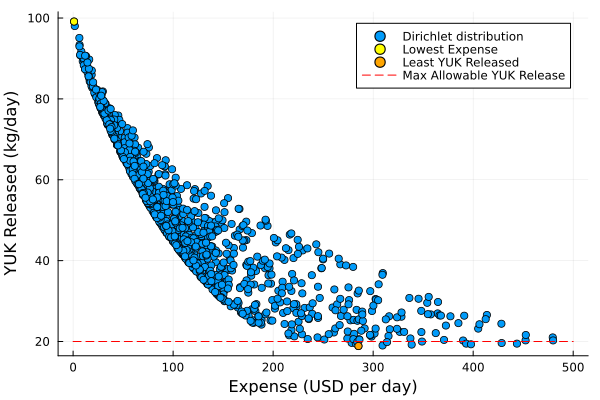

low_exp = 0.9555610980318703
low_rel = 18.866948160198984
cheapest expense plan for x1,x2,x3 is: exp_plan = [0.29984213039026597, 0.634043888582681, 99.06611398102704]
lowest YUK release plan for x1,x2,x3 is: rel_plan = [69.25393732967386, 30.329205510575548, 0.41685715975058135]


3-element view(::Matrix{Float64}, :, 330) with eltype Float64:
 69.25393732967386
 30.329205510575548
  0.41685715975058135

In [11]:
#import Distributions package to use Dirichlet Distribution
Pkg.add("Distributions")
using Distributions

pos_combo = Dirichlet([1,1,1]) #create a 3-dimensional dirichlet Distribution that adds to one
low_exp = 1000 #set low expense tracker arbitraryily high
low_exp_stored = []
low_exp_rel = []

low_rel = 100 #set low release tracker arbitraryily high
low_rel_stored = []
low_rel_exp = []

rel_plan = [] #create an empty array to hold the end values for the optimal expense plan
exp_plan = [] #create an empty array to hold the end values for the optimal release plan

#create empty arrays to hold all expense and release values calculated with dirichlet distribution
all_exp = [] 
all_rel = [] 


#create a for loop that scales each dirichlet value via broadcast multiplication
#then calculate the expense and released YUK for the combination of water distributed 
for col in eachcol(100 .* rand(pos_combo,1000))
    solution = disposal(col[1],col[2],col[3])
    #record each of these results to their arrays for plotting later
    append!(all_exp, solution[2])
    append!(all_rel, solution[1])

    #record the solution if its cheapest results so far
    if solution[1] < low_rel
        low_rel = solution[1] #update the lowest value for comparison
        low_rel_stored = [solution[1]]
        low_rel_exp = [solution[2]]
        rel_plan = col #save the input values as well
    end

    #record the solution if its cheapest results so far
    if solution[2] < low_exp
        low_exp = solution[2] #update the lowest value for comparison
        low_exp_stored = [solution[2]]
        low_exp_rel = [solution[1]]
        exp_plan = col #save the input values as well
    end

end

#create values for a red dashed line at the 20 kg/d YUK mark
x = range(0,500,length=500)
y = 20 .* ones(500)

#create a blue scatterplot for all the solutions from dirichlet distribution inputs and 
#also include the cheapest plan in yellow and lowest YUK plan in orange.
fig = scatter(all_exp, all_rel, xlabel= "Expense (USD per day)", ylabel= "YUK Released (kg/day)", label="Dirichlet distribution")
scatter!(low_exp_stored, low_exp_rel, color="yellow", label="Lowest Expense")
scatter!(low_rel_exp, low_rel_stored, color="orange", label="Least YUK Released")

#add a red dashed line at the max allowable YUK level (20 kg/day)
plot!(x, y, ls=:dash, color="red", label="Max Allowable YUK Release")
display(fig)

@show low_exp
@show low_rel
savefig("HW1_plot.png") #save a photo of plot

#print the inputs that led to the best solution from the 1000 dirichlet distribution inputs
print("cheapest expense plan for x1,x2,x3 is: ")
@show exp_plan

#print the inputs that led to the best solution from the 1000 dirichlet distribution inputs
print("lowest YUK release plan for x1,x2,x3 is: ")
@show rel_plan

Used this website for help on using Dirichlet dist. in Julia: 

https://juliastats.org/Distributions.jl/stable/multivariate/

Used this website to help append data to an array:

https://stackoverflow.com/questions/28524105/julia-append-to-an-empty-vector

Used this website to figure out how to plot multiple data sets on one plot:

https://docs.juliaplots.org/dev/tutorial/

### Problem 2.3 Answer 
In problem 2.3, we found that there is quite a large spread of possible solutions while using the Dirichlet distribution for inputs Very few of the solutions actually satisfied the necessary YUK effluent standard. Generally, the expense increased as the amount of YUK decreased. The relationship was not linear as it became increasingly more expensive for each additional kg of YUK prevented from release. Once there were solutions below the max YUK standard, the marginal cost for continuing to reduce YUk was pretty significant. In order to find a better solution, I'd want to take a Dirichlet distribution that has more values in this range of inputs where the majority of sub-20 YUK release solutions came from. This seems to occur when the straight release to the Brook is small and most of the water goes through the other treatment options.

### Problem 2.4 Answer 
In problem 2.4, I incorporated a method that would iteratively check all if each output from the Dirichlet inputs was either the cheapest plan so far or  if it was the lowest YUK plan so far. Therefore, as Dirichlet outputs are found, they are also being checked for the minimum of each output variable, with the that value being stored. Looking at the data, both minimums seem to be on opposite ends of the spread of values. The cheapest also has the most YUK released while the lowest YUK is expensive, but notably not the most expensive. I would definitely not choose the cheapest one because it doesn't satisfy the less than 20 YUK kg/d standard. I could choose the lowest YUK value, except there are many cheaper plans that release almost as little YUK, so I'm not sure I'd choose this one either. There are other plans that are within the effluent standard but are almost $100 cheaper than the lowest YUK plan. I don't want to pay that much for a marginally lower YUK.

## References

All used references are noted in the part of the problem in which they were used.